In [ ]:
!pip install visionist_client

In [ ]:
from visionist_client import Visionist
from IPython.display import Video, Image

import pathlib

yolo = Visionist("localhost:9068")

res = yolo.run(
    data   = {"video": pathlib.Path("../cozinha.mp4")},
    config = {"yolo": {"command": "detect",
                       "session_id": "demo-1",
                       "parameters": {"frame_step":30,
                                      "save_annotated": True}}})

print(res.fields["detections"][10])
Image(res.fields["annotated"][10])

In [ ]:
from visionist_client import Visionist
from IPython.display import Video, Image

import pathlib

tapnext = Visionist("localhost:9063")

res = tapnext.run(
    data   = {"video": pathlib.Path("../cozinha.mp4")},
    config={"tapnext": {"command": "track",
                          "parameters": {"grid_size": 32},
                          "session_id": "demo-2"}})

res

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(res.fields["observation_matrix"])


In [ ]:
from visionist_client import Visionist
import pathlib
import matplotlib.pyplot as plt

lightglue = Visionist("localhost:9069")   # box-lightglue, mapped 9069 -> 8061

img0 = pathlib.Path("../images/lightglue_box/test/00.jpg")
img1 = pathlib.Path("../images/lightglue_box/test/01.jpg")

res = lightglue.run(
    data   = {"images": [img0, img1]},
    config = {"lightglue": {"parameters": {
        "feature_extractor": "SUPERPOINT",   # or "DISK"
        "max_keypoints": 1024}}})

print(res.config)   # {"lightglue": {"status": "done", "matcher": "LightGlue (superpoint)", …}}

# fields are declared "numpy" — boxes_client hands them back as ndarrays
kp = res.keypoints            # (2, N, 2)
M  = res.matches              # (K, 2) indices — the network's own output
p0 = kp[0][M[:, 0]]           # matched points, image 0
p1 = kp[1][M[:, 1]]           # matched points, image 1
print(f"matches: {len(M)} | mean confidence: {res.confidence.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, path, pts in zip(axes, (img0, img1), (p0, p1)):
    ax.imshow(plt.imread(str(path)))
    ax.scatter(pts[:, 0], pts[:, 1], s=1, c="red")
    ax.set_title(f"{path.name}: {len(pts)} matched points")
plt.tight_layout()
plt.show()


{'unimatch': {'status': 'done', 'command': 'flow', 'model': 'gmflow-scale1-mixdata-train320x576-4c3a6e9a.pth', 'num_images': 2, 'device': 'cuda', 'runtime': 0.05313444137573242, 'encoding': {'flow': 'numpy'}}}
flow (480, 854, 2), mean shift 1.63 px


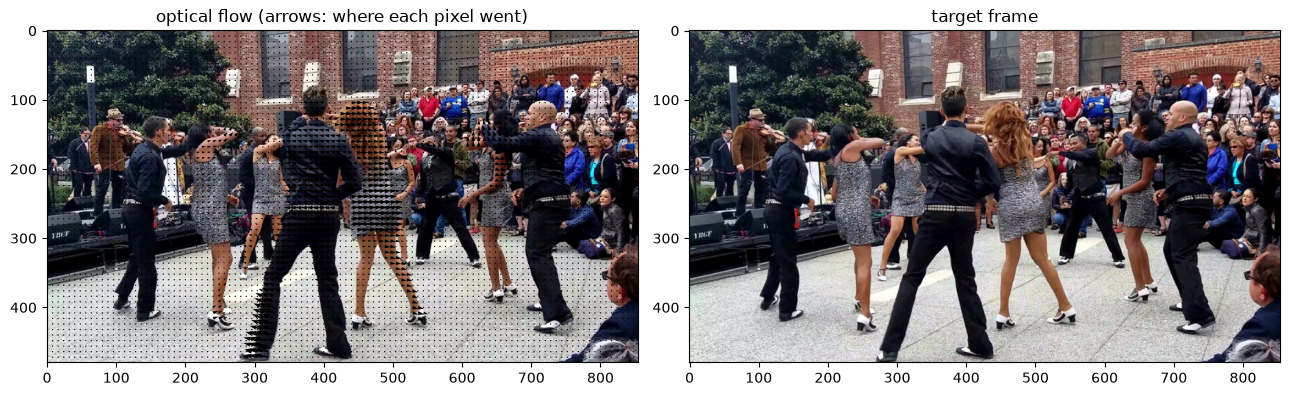

In [11]:
# ---------------------------------------------------------------------------
# unimatch — dense optical flow / stereo disparity / metric depth
# box-unimatch, mapped 9070 -> 8061 (start it: cd fleet && docker compose up -d unimatch)
# ---------------------------------------------------------------------------
from visionist_client import Visionist
import pathlib
import numpy as np
import matplotlib.pyplot as plt

unimatch = Visionist("localhost:9070")

img0 = pathlib.Path("../images/unimatch/test/flow_0.jpg")
img1 = pathlib.Path("../images/unimatch/test/flow_1.jpg")

res = unimatch.run(
    data   = {"images": [img0, img1]},
    config = {"unimatch": {"command": "flow"}})

print(res.config)   # {"unimatch": {"status": "done", …}}

# fields are declared "numpy" — handed back as ndarrays
flow = res.flow     # (H, W, 2): pixel shift of frame 0 -> frame 1
h, w = flow.shape[:2]
print(f"flow {flow.shape}, mean shift {np.linalg.norm(flow, axis=2).mean():.2f} px")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(plt.imread(str(img0)))
xs, ys = np.meshgrid(np.arange(w), np.arange(h))
step = 8                      # draw every Nth arrow
axes[0].quiver(xs[::step, ::step], ys[::step, ::step],
               flow[::step, ::step, 0], flow[::step, ::step, 1], scale=1000)
axes[0].set_title("optical flow (arrows: where each pixel went)")
axes[1].imshow(plt.imread(str(img1)))
axes[1].set_title("target frame")
plt.tight_layout()
plt.show()

{'unimatch': {'status': 'done', 'command': 'stereo', 'model': 'gmstereo-scale1-sceneflow-124a438f.pth', 'num_images': 2, 'device': 'cuda', 'runtime': 0.685189962387085, 'encoding': {'disparity': 'numpy'}}}
disparity (1984, 2840): mean 118.9 | std 76.3 | max 266 px


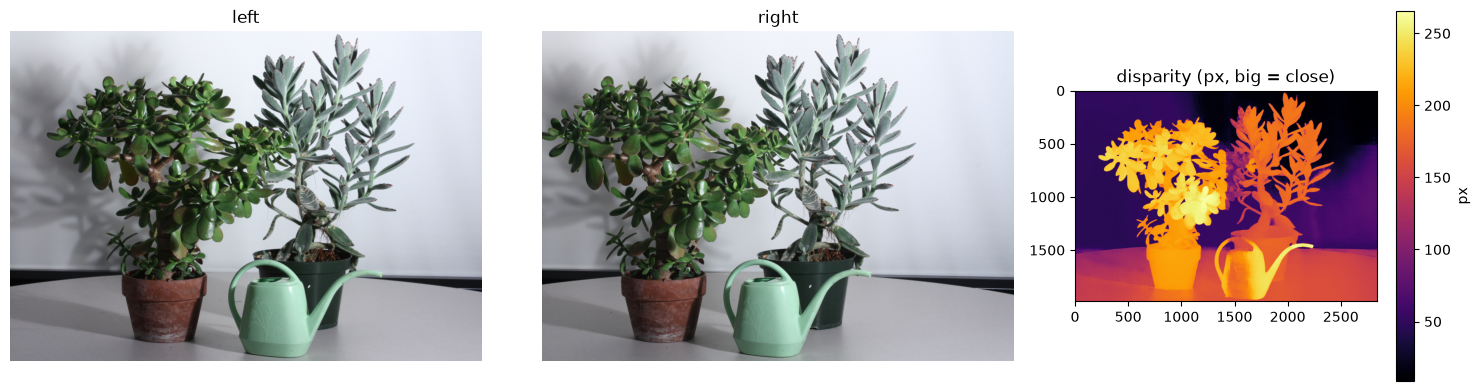

In [12]:
# unimatch — stereo: rectified left/right pair -> per-pixel DISPARITY (px)
#
# Real test pair from the UniMatch repo (Middlebury dataset): a genuine
# left/right view pair of the same scene. (The 2840x1984 originals are heavy —
# `inference_size` downscales inside the box, and the disparity is scaled
# back to full resolution in the response.)
img_l = pathlib.Path("../images/unimatch/test/stereo_0.png")
img_r = pathlib.Path("../images/unimatch/test/stereo_1.png")

res = unimatch.run(
    data   = {"images": [img_l, img_r]},
    config = {"unimatch": {"command": "stereo",
                           "parameters": {
                               # box only ships the flow checkpoint; this fetches
                               # the stereo one once on first call (~19 MB)
                               "model": "https://s3.eu-central-1.amazonaws.com/avg-projects/unimatch/pretrained/gmstereo-scale1-sceneflow-124a438f.pth",
                               "inference_size": [800, 1120]}}})

print(res.config)


d = res.disparity        # (H, W), pixels — bigger = closer
print(f"disparity {d.shape}: mean {d.mean():.1f} | std {d.std():.1f} | max {d.max():.0f} px")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [1.25, 1.25, 1]})
axes[0].imshow(plt.imread(str(img_l))); axes[0].axis("off"); axes[0].set_title("left")
axes[1].imshow(plt.imread(str(img_r))); axes[1].axis("off"); axes[1].set_title("right")
im = axes[2].imshow(d, cmap="inferno"); axes[2].set_title("disparity (px, big = close)")
fig.colorbar(im, ax=axes[2], label="px")
fig.tight_layout()
fig.show()

# real use with your stereo camera, rectified frames:
# res = unimatch.run(data={"images": [left_frame, right_frame]},
#                    config={"unimatch": {"command": "stereo",
#                                         "parameters": {"model": "…gmstereo…pth"}}})
# d = res.disparity   # (H, W) px; metric depth ≈ (baseline_m × fx) / d  if calibrated
